# Ergebnisse – Experiment-Summary
- Pro Experiment & Datensatz eine Tabelle (mit `n_runs` bei Exp 1/2/4); Bar-Chart bei Exp 1/2/4, Exp 3 nur SHAP-Tabelle
- Quelle: alle MLflow-Runs aus `./mlruns`; fehlende/leere Experimente werden übersprungen

In [8]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Runs laden
- Nur vorhandene Experimente aus `./mlruns`; leere/fehlende werden übersprungen

In [9]:
mlflow.set_tracking_uri("file:./mlruns")

experiments = [f"{ds}_experiment_{i}" for ds in ["fake_jobs", "airbnb_paris"] for i in [1, 2, 3, 4]]

parts = []
for name in experiments:
    exp = mlflow.get_experiment_by_name(name)
    if exp is None:
        continue
    runs = mlflow.search_runs([exp.experiment_id])
    if len(runs) == 0:
        continue
    runs["experiment"] = name
    parts.append(runs)

df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(f"{len(df)} Runs aus {len(parts)} Experimenten geladen")

273 Runs aus 8 Experimenten geladen


## Aufbereiten
- Datensatz / Experiment-Nr. / Modellname ableiten; Metrik-Spalten vereinheitlichen

In [10]:
datasets = ["fake_jobs", "airbnb_paris"]

if len(df):
    df["exp_num"] = df["experiment"].str.split("_").str[-1].astype(int)
    df["dataset"] = df["experiment"].str.rsplit("_experiment_", n=1).str[0]
    df["model"] = df["tags.mlflow.runName"] if "tags.mlflow.runName" in df.columns else df["run_id"]
    df = df[df["model"] != "contexttab_fixed"]  # veralteten Run ausschließen
    df = df.rename(columns={"metrics.average_precision": "AP", "metrics.auc_roc": "AUROC", "metrics.runtime_s": "runtime_s"})
    for col in ["AP", "AUROC", "runtime_s"]:
        if col not in df.columns:
            df[col] = np.nan
    print("Datensätze:", df["dataset"].unique().tolist(), "| Experimente:", sorted(df["exp_num"].unique()))

Datensätze: ['fake_jobs', 'airbnb_paris'] | Experimente: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Experiment 1 – Unsupervised Outlier Detection
- TFMs (TabPFN unsup., AnoLLM, FoMo-OD) vs. PyOD-Baselines; AP & AUROC je Modell

=== Experiment 1 – fake_jobs ===


,AP,AUROC,runtime_s,n_runs
model,,,,
anollm,0.0975,0.6158,5556.0423,3
autoencoder,0.0902,0.6296,11786.1575,3
iforest,0.0872,0.5971,2.2746,4
ecod,0.0772,0.5980,0.4629,4
loda,0.0697,0.5556,0.8395,4
tabpfn_unsup,0.0630,0.5244,470.9756,4
fomo_od,0.0626,0.6013,0.2353,3


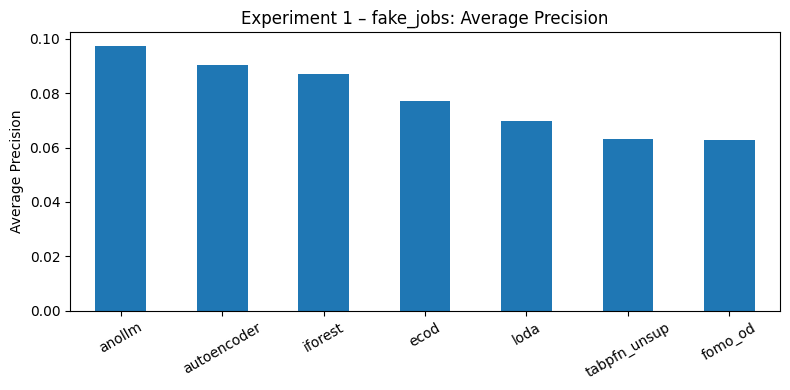

=== Experiment 1 – airbnb_paris ===


,AP,AUROC,runtime_s,n_runs
model,,,,
ecod,0.0871,0.7037,0.7907,3
iforest,0.0749,0.6883,2.0244,3
anollm,0.0728,0.6503,7095.1032,3
loda,0.0560,0.5437,1.8207,3
autoencoder,0.0555,0.6174,11799.6856,3
tabpfn_unsup,0.0472,0.5860,1954.4613,3
fomo_od,0.0430,0.5232,0.2810,3


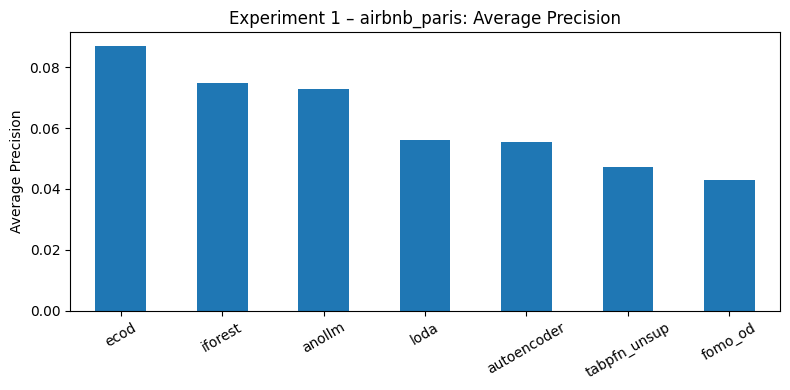

In [11]:
for ds in datasets:
    sub = df[(df["exp_num"] == 1) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-1-Runs")
        continue
    g = sub.groupby("model")
    tab = g[["AP", "AUROC", "runtime_s"]].mean()
    tab["n_runs"] = g.size()
    tab = tab.sort_values("AP", ascending=False).round(4)
    print(f"=== Experiment 1 – {ds} ===")
    display(tab)
    ax = tab["AP"].plot.bar(figsize=(8, 4), rot=30)
    ax.set_title(f"Experiment 1 – {ds}: Average Precision")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

## Experiment 2 – Enhanced Baseline-Modelle
- Baselines auf cleaned vs. semantisch vs. enhanced vs. enhanced+semantisch (AP je Detektor)
- Hinweis: enhanced ist semi-supervised (Label-Leakage), nicht direkt mit unsupervised vergleichbar

=== Experiment 2 – fake_jobs (AP & n_runs je Detektor × Repräsentation) ===


AP                                                  \
params.representation cleaned enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                                 
autoencoder            0.0817   0.6082         0.6249                  0.2060   
ecod                   0.0764   0.1540         0.1100                  0.0825   
iforest                0.0873   0.1772         0.1455                  0.1109   
loda                   0.0538   0.1922         0.1237                  0.0448   

                                                               n_runs  \
params.representation semantic semantic_pca100 semantic_pca30 cleaned   
params.detector                                                         
autoencoder             0.0630          0.0818         0.0969       4   
ecod                    0.0436          0.0460         0.0587       5   
iforest                 0.0515          0.0570         0.0867       5   
loda                    0.0485          0.0452         0.0387       5   

                                                                       \
params.representation enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                         
autoencoder                  3              3                       3   
ecod                         3              3                       3   
iforest                      3              3                       3   
loda                         3              3                       3   

                                                               
params.representation semantic semantic_pca100 semantic_pca30  
params.detector                                                
autoencoder                  1               2              3  
ecod                         1               2              3  
iforest                      3               2              3  
loda                         3               2              3

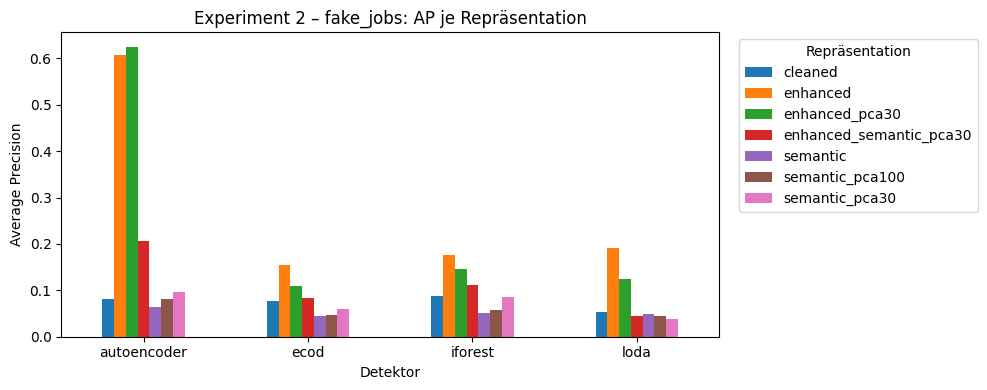

=== Experiment 2 – airbnb_paris (AP & n_runs je Detektor × Repräsentation) ===


AP                                                  \
params.representation cleaned enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                                 
autoencoder            0.0690   0.3234         0.4760                  0.1823   
ecod                   0.1042   0.0688         0.2705                  0.1462   
iforest                0.0850   0.1322         0.2406                  0.1001   
loda                   0.0840   0.0776         0.1982                  0.0705   

                                                               n_runs  \
params.representation semantic semantic_pca100 semantic_pca30 cleaned   
params.detector                                                         
autoencoder             0.0457          0.0512         0.0598       3   
ecod                    0.0450          0.0677         0.0846       3   
iforest                 0.0460          0.0698         0.0797       3   
loda                    0.0489          0.0514         0.0701       3   

                                                                       \
params.representation enhanced enhanced_pca30 enhanced_semantic_pca30   
params.detector                                                         
autoencoder                  3              3                       3   
ecod                         3              3                       3   
iforest                      3              3                       3   
loda                         3              3                       3   

                                                               
params.representation semantic semantic_pca100 semantic_pca30  
params.detector                                                
autoencoder                  1               2              3  
ecod                         1               2              3  
iforest                      1               2              3  
loda                         1               2              3

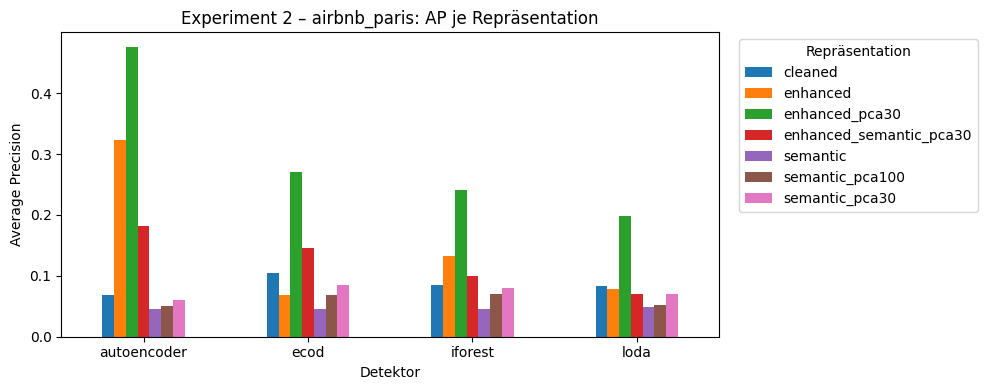

In [12]:
for ds in datasets:
    sub = df[(df["exp_num"] == 2) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-2-Runs")
        continue
    piv = sub.pivot_table(index="params.detector", columns="params.representation", values="AP", aggfunc=["mean", "size"]).round(4)
    piv = piv.rename(columns={"mean": "AP", "size": "n_runs"}, level=0)
    print(f"=== Experiment 2 – {ds} (AP & n_runs je Detektor × Repräsentation) ===")
    display(piv)
    ax = piv["AP"].plot.bar(figsize=(10, 4), rot=0)
    ax.set_title(f"Experiment 2 – {ds}: AP je Repräsentation")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("Detektor")
    ax.legend(title="Repräsentation", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Experiment 3 – Semantische Relevanz (SHAP)
- ConTextTab-SHAP: wichtigste Features je Datensatz (nur Tabelle)

In [13]:
for ds in datasets:
    sub = df[(df["exp_num"] == 3) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        continue
    rel_cols = [c for c in sub.columns if c.startswith("metrics.") and not c.endswith("_total") and sub[c].notna().any()]
    rel = sub.iloc[0][rel_cols].dropna().astype(float)
    rel.index = [c.replace("metrics.", "") for c in rel.index]
    rel = rel.sort_values(ascending=False).round(4)
    display(rel.to_frame(f"{ds} – mean_abs_shap"))

,fake_jobs – mean_abs_shap
text_description,0.0068
text_title,0.0049
text_requirements,0.0042
text_company_profile,0.0016
text_benefits,0.0010


,airbnb_paris – mean_abs_shap
text_neighborhood_overview,0.0081
text_host_about,0.0071
text_name,0.0055
text_description,0.0052


## Experiment 4 – TFMs zur binären Klassifikation
- ConTextTab vs. TabPFN-Klassifikation; AP & AUROC je Modell

=== Experiment 4 – fake_jobs ===


,AP,AUROC,runtime_s,n_runs
model,,,,
tabpfn_classification,0.7657,0.9578,6.3596,17
contexttab,0.1789,0.4987,32.4840,13


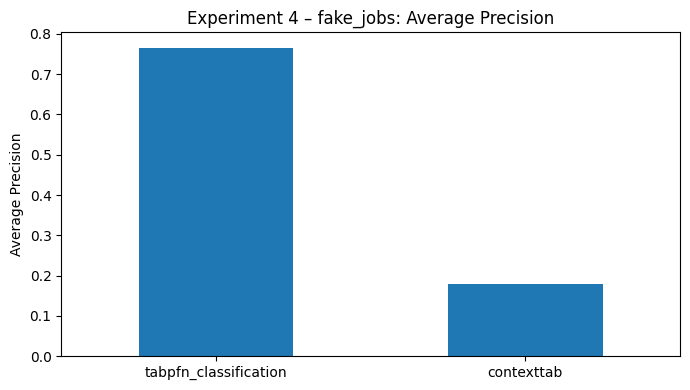

=== Experiment 4 – airbnb_paris ===


,AP,AUROC,runtime_s,n_runs
model,,,,
tabpfn_classification,0.4353,0.8737,4.8880,11
contexttab,0.3087,0.7291,50.0512,13


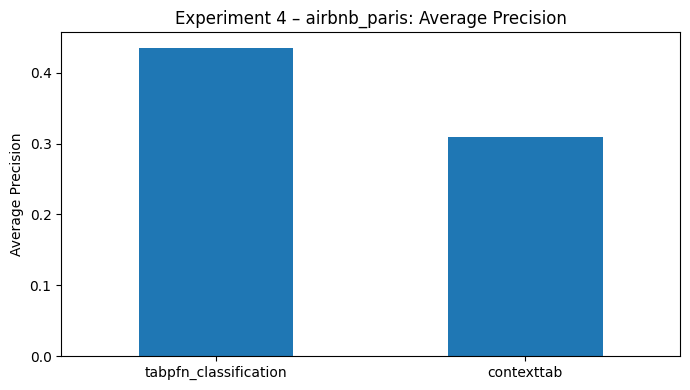

In [14]:
for ds in datasets:
    sub = df[(df["exp_num"] == 4) & (df["dataset"] == ds)] if len(df) else df
    if not len(sub):
        print(f"{ds}: keine Exp-4-Runs")
        continue
    g = sub.groupby("model")
    tab = g[["AP", "AUROC", "runtime_s"]].mean()
    tab["n_runs"] = g.size()
    tab = tab.sort_values("AP", ascending=False).round(4)
    print(f"=== Experiment 4 – {ds} ===")
    display(tab)
    ax = tab["AP"].plot.bar(figsize=(7, 4), rot=0)
    ax.set_title(f"Experiment 4 – {ds}: Average Precision")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()